# 1. Comprension del negocio

## 1.1 Tipo de industria

Para el desarrollo de este ejercicio asumiremos el papel de una compañia de exploracion minera centrada en la busqueda de depositos de oro de alta ley en Estados Unidos.

En terminos generales, en el negocio de la mineria la primera etapa es la exploracion geologica, cuya mision es buscar y encontrar el mineral de interes en cantidad, calidad, forma, y ubicacion adecuadas para que sea economicamente factible su extraccion.

Antes de iniciar con la planificacion y despliegue de una campaña de exploracion es necesario conocer la informacion disponible relacionada al mineral de interes, esta informacion es generalmente generada por instituciones gubernamentales o compañias privadas que han trabajado en el area. 

## 1.2 Mision

Desarrollar un analisis exploratorio de los datos derivados de muestras de roca colectadas en Estados Unidos, con el objetivo de identificar los tipos de deposito con mayores concentraciones de Au y los lugares (Estados) donde ocurren con mayor frecuencia.

Este tipo de analisis es de suma importancia dado que proporciona una de las herramientas necesarias para la toma de decisiones de negocio, como por ejemplo, en que lugar o lugares priorizar los esfuerzos de exploracion.

La combinacion en terreno de variales favorables para la presencia del mineral buscado disminuye la incertidumbre, aumentando las probabilidades de exito. 

## 1.3 Informacion disponible (Dataset)

El dataset escogido fue descargado del sitio web del Servicio Geologico Australiano (https://portal.ga.gov.au/) y proporciona análisis geoquímicos de más de 26.000 muestras únicas recopiladas en o cerca de depósitos minerales de 60 países, compilados por la Iniciativa de Mapeo de Minerales Críticos (CMMI), una colaboración entre Geoscience Australia (GA), el Geological Survey of Canada (GSC) y el United States Geological Survey (USGS). Los datos se compilaron a partir de varias fuentes de acceso público, incluidas bases de datos gubernamentales federales y provinciales de depósitos minerales y geoquímica, y la base de datos de muestras de mineral normalizadas según la abundancia cortical promedio (OSNACA) recopilada por el Centro para la Exploración Dirigida de la Universidad de Australia Occidental. Los datos geoquímicos cubren la mayor parte de la tabla periódica, con metadatos sobre métodos analíticos y límites de detección. Cuando están disponibles, las descripciones de las muestras incluyen litología, mineralogía y unidades estratigráficas de acogida. Los depósitos minerales se clasifican de acuerdo con el esquema de clasificación de depósitos minerales de la CMMI (Hofstra et al., 2021). La información de ubicación incluye el nombre del depósito o prospecto, y la ubicación de muestreo (es decir, mina, sitio de campo o boca de sondeo).

Link para descarga del dataset: https://critical-minerals.prod-geoserver.gis.ga.gov.au/geoserver/wfs?request=GetFeature&service=WFS&version=1.1.0&typeName=cmmi:CriticalMineralDepositsGeochemistry&outputFormat=excel2007&srsName=EPSG:4326

# 2. Inspeccion, filtrado y limpieza del dataset

In [1509]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1510]:
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 2.1 Inspeccion

In [1512]:
df = pd.read_csv("CriticalMineralDepositsGeochemistry.csv")

C:\TEMP\ipykernel_21768\3500585744.py:1: DtypeWarning: Columns (8,9,14,17,24,25,26,27,29,31,32,33,34,39,42,45,48,51,54,57,60,63,66,69,72,75,78,81,84,87,90,93,95,97,103,109,112,124,127,130,139,154,157,160,163,166,172,175,181,184,187,190,193,199,202,205,208,214,220,226,229,235,238,241,247,250,253,256,268,271,283,292,298,313,335,336,338) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CriticalMineralDepositsGeochemistry.csv")


Dataset con problemas relacionados a tipos de datos mezclados

In [1514]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29087 entries, 0 to 29086
Columns: 341 entries, FID to SAMPLE_GEOMETRY
dtypes: float64(201), object(140)
memory usage: 75.7+ MB


In [1515]:
df.head()

,FID,DEPOSIT_ANALYSIS_ID,DEPOSIT_UID,DEPOSIT_NAME,DEPOSIT_LOCAL_ID,DEPOSIT_ENVIRONMENT,DEPOSIT_GROUP,DEPOSIT_TYPE,PRIMARY_COMMODITIES,SECONDARY_COMMODITIES,ALL_COMMODITIES,DEPOSIT_SOURCE,SAMPLE_UID,SAMPLE_NAME,SAMPLE_LOCAL_ID,FEATURE_TYPE,FEATURE_NAME,FEATURE_UID,TOP_DEPTH_M,BASE_DEPTH_M,SAMPLE_DEPOSIT_RELATION,SAMPLE_TYPE,SAMPLING_METHOD,MATERIAL_CLASS,PROVINCE,STRAT_UNIT_NAME,STRAT_UNIT_UID,STRAT_GROUPING,EARTH_MATERIAL_GROUP,EARTH_MATERIAL_QUALIFIER,EARTH_MATERIAL,MODE_OCCURRENCE,ALTERATION,TEXTURE,MINERALS,SAMPLE_DESCRIPTION,SAMPLE_PREPARATION,SIO2_WT_PERCENT,SIO2_DETECTION_LIMIT,SIO2_METHOD,TIO2_WT_PERCENT,TIO2_DETECTION_LIMIT,TIO2_METHOD,AL2O3_WT_PERCENT,AL2O3_DETECTION_LIMIT,AL2O3_METHOD,FE2O3TOT_WT_PERCENT,FE2O3TOT_DETECTION_LIMIT,FE2O3TOT_METHOD,FE2O3_WT_PERCENT,FE2O3_DETECTION_LIMIT,FE2O3_METHOD,FEO_WT_PERCENT,FEO_DETECTION_LIMIT,FEO_METHOD,MNO_WT_PERCENT,MNO_DETECTION_LIMIT,MNO_METHOD,MGO_WT_PERCENT,MGO_DETECTION_LIMIT,MGO_METHOD,CAO_WT_PERCENT,CAO_DETECTION_LIMIT,CAO_METHOD,NA2O_WT_PERCENT,NA2O_DETECTION_LIMIT,NA2O_METHOD,K2O_WT_PERCENT,K2O_DETECTION_LIMIT,K2O_METHOD,P2O5_WT_PERCENT,P2O5_DETECTION_LIMIT,P2O5_METHOD,H2OPLUS_WT_PERCENT,H2OPLUS_DETECTION_LIMIT,H2OPLUS_METHOD,H2OMINUS_WT_PERCENT,H2OMINUS_DETECTION_LIMIT,H2OMINUS_METHOD,H2OTOTAL_WT_PERCENT,H2OTOTAL_DETECTION_LIMIT,H2OTOTAL_METHOD,CO2_WT_PERCENT,CO2_DETECTION_LIMIT,CO2_METHOD,SO3_WT_PERCENT,SO3_DETECTION_LIMIT,SO3_METHOD,MLOI_WT_PERCENT,MLOI_DETECTION_LIMIT,MLOI_METHOD,LOITOT_WT_PERCENT,LOITOT_DETECTION_LIMIT,LOITOT_METHOD,REST_WT_PERCENT,REST_METHOD,TOTAL_WT_PERCENT,TOTAL_METHOD,AG_PPM,AG_DETECTION_LIMIT,AG_METHOD,AL_PPM,AL_DETECTION_LIMIT,AL_METHOD,AS_PPM,AS_DETECTION_LIMIT,AS_METHOD,AU_PPB,AU_DETECTION_LIMIT,AU_METHOD,B_PPM,B_DETECTION_LIMIT,B_METHOD,BA_PPM,BA_DETECTION_LIMIT,BA_METHOD,BE_PPM,BE_DETECTION_LIMIT,BE_METHOD,BI_PPM,BI_DETECTION_LIMIT,BI_METHOD,BR_PPM,BR_DETECTION_LIMIT,BR_METHOD,C_WT_PERCENT,C_DETECTION_LIMIT,C_METHOD,CA_PPM,CA_DETECTION_LIMIT,CA_METHOD,CD_PPM,CD_DETECTION_LIMIT,CD_METHOD,CE_PPM,CE_DETECTION_LIMIT,CE_METHOD,CL_PPM,CL_DETECTION_LIMIT,CL_METHOD,CO_PPM,CO_DETECTION_LIMIT,CO_METHOD,CR_PPM,CR_DETECTION_LIMIT,CR_METHOD,CS_PPM,CS_DETECTION_LIMIT,CS_METHOD,CU_PPM,CU_DETECTION_LIMIT,CU_METHOD,DY_PPM,DY_DETECTION_LIMIT,DY_METHOD,ER_PPM,ER_DETECTION_LIMIT,ER_METHOD,EU_PPM,EU_DETECTION_LIMIT,EU_METHOD,F_PPM,F_DETECTION_LIMIT,F_METHOD,FE_PPM,FE_DETECTION_LIMIT,FE_METHOD,GA_PPM,GA_DETECTION_LIMIT,GA_METHOD,GD_PPM,GD_DETECTION_LIMIT,GD_METHOD,GE_PPM,GE_DETECTION_LIMIT,GE_METHOD,HF_PPM,HF_DETECTION_LIMIT,HF_METHOD,HG_PPB,HG_DETECTION_LIMIT,HG_METHOD,HO_PPM,HO_DETECTION_LIMIT,HO_METHOD,IN_PPM,IN_DETECTION_LIMIT,IN_METHOD,IR_PPM,IR_DETECTION_LIMIT,IR_METHOD,K_PPM,K_DETECTION_LIMIT,K_METHOD,LA_PPM,LA_DETECTION_LIMIT,LA_METHOD,LI_PPM,LI_DETECTION_LIMIT,LI_METHOD,LU_PPM,LU_DETECTION_LIMIT,LU_METHOD,MG_PPM,MG_DETECTION_LIMIT,MG_METHOD,MN_PPM,MN_DETECTION_LIMIT,MN_METHOD,MO_PPM,MO_DETECTION_LIMIT,MO_METHOD,NA_PPM,NA_DETECTION_LIMIT,NA_METHOD,NB_PPM,NB_DETECTION_LIMIT,NB_METHOD,ND_PPM,ND_DETECTION_LIMIT,ND_METHOD,NI_PPM,NI_DETECTION_LIMIT,NI_METHOD,OS_PPB,OS_DETECTION_LIMIT,OS_METHOD,P_PPM,P_DETECTION_LIMIT,P_METHOD,PB_PPM,PB_DETECTION_LIMIT,PB_METHOD,PD_PPB,PD_DETECTION_LIMIT,PD_METHOD,PR_PPM,PR_DETECTION_LIMIT,PR_METHOD,PT_PPB,PT_DETECTION_LIMIT,PT_METHOD,RB_PPM,RB_DETECTION_LIMIT,RB_METHOD,RE_PPB,RE_DETECTION_LIMIT,RE_METHOD,RH_PPB,RH_DETECTION_LIMIT,RH_METHOD,RU_PPB,RU_DETECTION_LIMIT,RU_METHOD,S_PPM,S_DETECTION_LIMIT,S_METHOD,SB_PPM,SB_DETECTION_LIMIT,SB_METHOD,SC_PPM,SC_DETECTION_LIMIT,SC_METHOD,SE_PPM,SE_DETECTION_LIMIT,SE_METHOD,SI_PPM,SI_DETECTION_LIMIT,SI_METHOD,SM_PPM,SM_DETECTION_LIMIT,SM_METHOD,SN_PPM,SN_DETECTION_LIMIT,SN_METHOD,SR_PPM,SR_DETECTION_LIMIT,SR_METHOD,TA_PPM,TA_DETECTION_LIMIT,TA_METHOD,TB_PPM,TB_DETECTION_LIMIT,TB_METHOD,TE_PPM,TE_DETECTION_LIMIT,TE_METHOD,TH_PPM,TH_DETECTION_LIMIT,TH_METHOD,TI_PPM,TI_DETECTION_LIMIT,TI_METHOD,TL_PPM,TL_DETECTION_LIMIT,TL_METHOD,TM_PPM,TM_DETECTION_LIMIT,TM_METHOD,U_PPM,U_DETECTION_LI

## 2.2 Filtrado y limpieza

El dataset contiene un gran numero de variables que no contribuyen al objetivo o no se relacionan con la variable de interes. Se creara una copia de dimension reducida con las variables mas informativas para disminuir el ruido conservando el dataset original.

In [1518]:
df_eda = df.copy()

In [1519]:
# A partir de este punto, todas las transformaciones se realizan sobre df_eda, preservando el dataset original.

# Para los propositos de este analisis algunas columnas resultan irrelevantes, asi que se conservaran aquellas 
# realmente informativas en relacion a la ocurrencia del mineral de interes (Oro).

cols_elim = df_eda.columns[0:3].tolist() + df_eda.columns[4:5].tolist() + df_eda.columns[10:12].tolist() + df_eda.columns[13:15].tolist() + df_eda.columns[16:18].tolist() + df_eda.columns[325:327].tolist() + df_eda.columns[329:].tolist()

df_eda = df_eda.drop(columns=cols_elim)

patron = ["O2", "O3", "LIMIT", "METHOD", "FEO", "MNO", "MGO", "CAO", "NAO2", "K2O", "P2O5", "H2OPLUS", "H2OMINUS", "H2OTOTAL", "MLOI", "LOITOT", "REST", "NA2O", "TOTAL_WT_PERCENT"]

cols1_elim = [col for col in df_eda.columns
             if any(pat in col for pat in patron)]

df_eda = df_eda.drop(columns=cols1_elim)

df_eda.head()

,DEPOSIT_NAME,DEPOSIT_ENVIRONMENT,DEPOSIT_GROUP,DEPOSIT_TYPE,PRIMARY_COMMODITIES,SECONDARY_COMMODITIES,SAMPLE_UID,FEATURE_TYPE,TOP_DEPTH_M,BASE_DEPTH_M,SAMPLE_DEPOSIT_RELATION,SAMPLE_TYPE,MATERIAL_CLASS,PROVINCE,STRAT_UNIT_NAME,STRAT_UNIT_UID,STRAT_GROUPING,EARTH_MATERIAL_GROUP,EARTH_MATERIAL_QUALIFIER,EARTH_MATERIAL,MODE_OCCURRENCE,ALTERATION,TEXTURE,MINERALS,SAMPLE_DESCRIPTION,SAMPLE_PREPARATION,AG_PPM,AL_PPM,AS_PPM,AU_PPB,B_PPM,BA_PPM,BE_PPM,BI_PPM,BR_PPM,C_WT_PERCENT,CA_PPM,CD_PPM,CE_PPM,CL_PPM,CO_PPM,CR_PPM,CS_PPM,CU_PPM,DY_PPM,ER_PPM,EU_PPM,F_PPM,FE_PPM,GA_PPM,GD_PPM,GE_PPM,HF_PPM,HG_PPB,HO_PPM,IN_PPM,IR_PPM,K_PPM,LA_PPM,LI_PPM,LU_PPM,MG_PPM,MN_PPM,MO_PPM,NA_PPM,NB_PPM,ND_PPM,NI_PPM,OS_PPB,P_PPM,PB_PPM,PD_PPB,PR_PPM,PT_PPB,RB_PPM,RE_PPB,RH_PPB,RU_PPB,S_PPM,SB_PPM,SC_PPM,SE_PPM,SI_PPM,SM_PPM,SN_PPM,SR_PPM,TA_PPM,TB_PPM,TE_PPM,TH_PPM,TI_PPM,TL_PPM,TM_PPM,U_PPM,V_PPM,W_PPM,Y_PPM,YB_PPM,ZN_PPM,ZR_PPM,LREE_PPM,HREE_PPM,REE_PPM,REE_Y_PPM,ANALYSIS_DATETIME,COUNTRY,STATE
0,Woodlawn,Volcanic basin hydrothermal,Volcanogenic massive sulfide (VMS),Bimodal felsic VMS,"Zn, Cu, Pb","Ag, Au",AU.1459664,borehole,NaN,NaN,unknown,borehole specimen,rock,Lachlan Orogen,ore horizon,NaN,ore horizon,fine grained siliciclastic rock,NaN,shale,NaN,NaN,NaN,NaN,"shale, alteration zone II",UNK,0.10,NaN,NaN,NaN,NaN,720.00,1.00,NaN,NaN,NaN,NaN,NaN,80.00,NaN,8.00,120.00,NaN,170.00,NaN,NaN,NaN,NaN,NaN,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.00,8.00,NaN,NaN,NaN,NaN,NaN,10.00,NaN,30.00,NaN,NaN,"1,150.00",NaN,NaN,NaN,130.00,NaN,NaN,NaN,"7,500.00",NaN,NaN,NaN,NaN,NaN,2.00,14.00,NaN,NaN,NaN,13.00,NaN,NaN,NaN,NaN,50.00,NaN,NaN,NaN,"3,100.00",65.00,92.00,0.00,92.00,92.00,1990-12-31,AUS,AU-NSW
1,Woodlawn,Volcanic basin hydrothermal,Volcanogenic massive sulfide (VMS),Bimodal felsic VMS,"Zn, Cu, Pb","Ag, Au",AU.1459665,borehole,NaN,NaN,unknown,borehole specimen,rock,Lachlan Orogen,NaN,NaN,NaN,acid volcanic rock,NaN,ash tuff,NaN,NaN,NaN,NaN,"tuff with possible coarse fragments,alteration...",UNK,NaN,NaN,33.00,NaN,NaN,920.00,3.00,1.00,NaN,NaN,NaN,NaN,120.00,NaN,-2.00,80.00,NaN,315.00,NaN,NaN,NaN,NaN,NaN,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.00,10.00,NaN,NaN,NaN,5.00,NaN,22.00,NaN,10.00,NaN,NaN,540.00,NaN,NaN,NaN,195.00,NaN,NaN,NaN,"6,600.00",NaN,NaN,NaN,NaN,NaN,3.00,11.00,NaN,NaN,NaN,30.00,NaN,NaN,NaN,5.00,-10.00,NaN,53.00,NaN,"1,750.00",138.00,159.00,0.00,159.00,212.00,1990-12-31,AUS,AU-NSW
2,Woodlawn,Volcanic basin hydrothermal,Volcanogenic massive sulfide (VMS),Bimodal felsic VMS,"Zn, Cu, Pb","Ag, Au",AU.1459702,borehole,NaN,NaN,unknown,borehole specimen,rock,Lachlan Orogen,NaN,NaN,NaN,basic intrusive rock,NaN,dolerite,NaN,NaN,NaN,NaN,"medium to coarse grained dolerite, alteration ...",UNK,3.00,NaN,24.00,NaN,NaN,320.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.00,280.00,NaN,182.00,NaN,NaN,NaN,NaN,NaN,20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN,NaN,NaN,NaN,NaN,4.00,NaN,110.00,NaN,NaN,100.00,NaN,NaN,NaN,15.00,NaN,NaN,NaN,500.00,NaN,NaN,NaN,NaN,NaN,1.00,70.00,NaN,NaN,NaN,70.00,NaN,NaN,NaN,NaN,375.00,NaN,25.00,NaN,"2,650.00",78.00,0.00,0.00,0.00,25.00,1990-12-31,AUS,AU-NSW
3,Woodlawn,Volcanic basin hydrothermal,Volcanogenic massive sulfide (VMS),Bimodal felsic VMS,"Zn, Cu, Pb","Ag, Au",AU.1459704,borehole,NaN,NaN,unknown,borehole specimen,rock,Lachlan Orogen,NaN,NaN,NaN,fine grained siliciclastic rock,NaN,shale,NaN,NaN,NaN,NaN,"shale, alteration zone I-II, hanging wall",UNK,0.10,NaN,NaN,NaN,NaN,"1,480.00",1.00,1.00,NaN,NaN,NaN,NaN,44.00,NaN,-2.00,75.00,NaN,120.00,NaN,NaN,NaN,NaN,NaN,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,NaN,NaN,NaN,NaN,NaN,12.00,NaN,-2.00,NaN,NaN,500.00,NaN,NaN,NaN,120.00,NaN,NaN,NaN,"2,100.00",NaN,NaN,NaN,NaN,NaN,5.00,9.00,NaN,NaN,NaN,19.00,NaN,NaN,NaN,NaN,140.00,NaN,10.00,NaN,"2,900.00",33.00,44.00,0.00,44.00,54.00,1990-12-31,AUS,AU-NSW
4,Woodlawn,Volcanic basin hydrothermal,Volcanogenic massive sulfide (VMS),Bimodal felsic VMS,"Zn, Cu, Pb","Ag, Au",AU.1459705,borehole,NaN,NaN,unknown,borehole specimen,rock,Lachlan Orogen,ore horizon

In [1520]:
df_eda.shape

(29087, 107)

Reduccion de 341 columnas a 107

In [1522]:
# Hay algunas columnas que al importar el dataset parecen tener tipos de datos mezclados o no adecuados para 
# analisis posterior

df_eda.dtypes

DEPOSIT_NAME            object
DEPOSIT_ENVIRONMENT     object
DEPOSIT_GROUP           object
DEPOSIT_TYPE            object
PRIMARY_COMMODITIES     object
                        ...   
REE_PPM                float64
REE_Y_PPM              float64
ANALYSIS_DATETIME       object
COUNTRY                 object
STATE                   object
Length: 107, dtype: object

La mayoria de las variables correspondientes a las concentraciones de cada elemento en la muestra aparecen como tipo object cuando debieran ser numericas (continuas). Los tipos de dato seran ajustados segun corresponda para posibilitar los analisis.

In [1524]:
cols_ppm_ppb = [col for col in df_eda.columns if col.endswith("_PPM") or col.endswith("_PPB")]

df_eda[cols_ppm_ppb] = df_eda[cols_ppm_ppb].apply(pd.to_numeric, errors="coerce")

In [1525]:
df_eda["AU_PPB"].dtype

dtype('float64')

In [1526]:
df_eda["ANALYSIS_DATETIME"] = pd.to_datetime(df_eda["ANALYSIS_DATETIME"], errors="coerce")

Para garantizar fiabilidad en conteos de variables categoricas se aplicara una homogenizacion

In [1528]:
cols_categ = ["DEPOSIT_NAME",	"DEPOSIT_ENVIRONMENT",	"DEPOSIT_GROUP",	"DEPOSIT_TYPE",	"PRIMARY_COMMODITIES",	"SECONDARY_COMMODITIES",	"FEATURE_TYPE",	"SAMPLE_DEPOSIT_RELATION",	"SAMPLE_TYPE",	"MATERIAL_CLASS",	"PROVINCE",	"STRAT_UNIT_NAME",	"STRAT_UNIT_UID",	"STRAT_GROUPING",	"EARTH_MATERIAL_GROUP",	"EARTH_MATERIAL_QUALIFIER",	"EARTH_MATERIAL",	"MODE_OCCURRENCE",	"ALTERATION",	"TEXTURE",	"MINERALS", "COUNTRY",	"STATE"]

df_eda[cols_categ] = (df_eda[cols_categ].astype(str).apply(lambda col: col.str.strip().str.title()))

Dado que el analisis se centrara en la variable "AU_PPB" (concentracion de Au en la muestra en partes por millon) se debe garantizar que no hayan valores faltantes o valores negativos

In [1530]:
df_eda["AU_PPB"].describe()

count       13,173.00
mean         4,726.89
std        119,161.06
min        -20,000.00
25%             47.00
50%            159.00
75%            479.00
max     10,800,000.00
Name: AU_PPB, dtype: float64

Algunos registros presentan valores negativos, lo cual es fisicamente imposible y por tanto se filtraran dichos registros para solo conservar valores > 0.


In [1532]:
df_eda[df_eda["AU_PPB"] < 0][["AU_PPB"]].head()

,AU_PPB
249,-1.00
322,-1.00
623,-1.00
649,-1.00
899,-1.00


In [1533]:
(df_eda["AU_PPB"] < 0).sum()

903

In [1534]:
df_eda["AU_PPB"].isna().sum()

15914

In [1535]:
df_eda = df_eda[df_eda["AU_PPB"] > 0]

(df_eda["AU_PPB"] < 0).sum()

0

In [1536]:
df_eda["AU_PPB"].describe()

count       12,270.00
mean         5,294.82
std        123,444.66
min              0.10
25%             65.00
50%            181.00
75%            529.75
max     10,800,000.00
Name: AU_PPB, dtype: float64

Dado que nos interesan solo las muestras colectadas en Estados Unidos (Usa) se creara una copia que solo contenga estas 

In [1538]:
df_eda["COUNTRY"].unique()

array(['Aus', 'Can', 'Irl', 'Jpn', 'Lao', 'Ita', 'Nam', 'Per', 'Phl',
       'Nzl', 'Pak', 'Png', 'Pol', 'Mmr', 'Mng', 'Mrt', 'Mli', 'Ind',
       'Idn', 'Chl', 'Chn', 'Fin', 'Gin', 'Deu', 'Esp', 'Egy', 'Cod',
       'Fji', 'Dom', 'Gab', 'Gbr', 'Gha', 'Zwe', 'Grc', 'Zaf', 'Zmb',
       'Vnm', 'Bra', 'Aut', 'Bgr', 'Bol', 'Usa', 'Sau', 'Rus', 'Sen',
       'Prt', 'Tur', 'Tha', 'Srb', 'Rou', 'Tun', 'Uga', 'Ven', 'Mex'],
      dtype=object)

In [1539]:
df_usa = df_eda[df_eda["COUNTRY"] == "Usa"].copy()

Antes de proceder con el analisis se verificara que no hayan muestras duplicadas

In [1541]:
df_usa["SAMPLE_UID"].nunique()

8261

In [1542]:
df_usa.shape

(8261, 107)

# 3. Analisis exploratorio de datos (EDA)

## 3.1 Analisis univariado

### 3.1.1 Variable numerica de interes - AU_PPB Estados Unidos

In [1546]:
df_usa["AU_PPB"].describe()

count       8,261.00
mean        2,295.72
std        30,977.26
min             0.10
25%            81.00
50%           176.00
75%           408.00
max     1,500,000.11
Name: AU_PPB, dtype: float64

Hay una distancia amplia entre la mediana y el maximo(176ppb vs 1,500,000ppb), tipico en depositos de oro en donde no es extraño encontrar ocasionalmente leyes extraordinariamente altas de este elemento, por tanto se usara escala logaritmica.

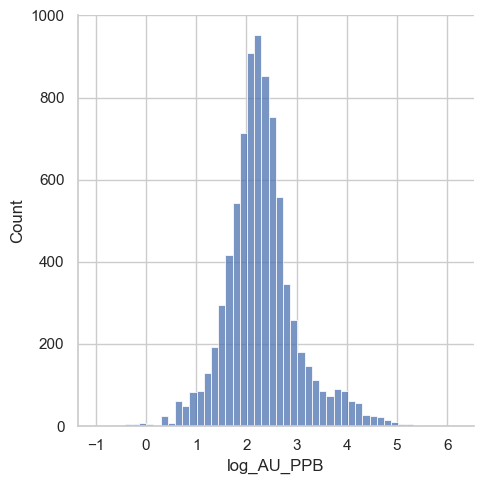

In [1548]:
df_usa["log_AU_PPB"] = np.log10(df_usa["AU_PPB"])

sns.displot(df_usa["log_AU_PPB"],bins=50)

<Axes: xlabel='log_AU_PPB'>

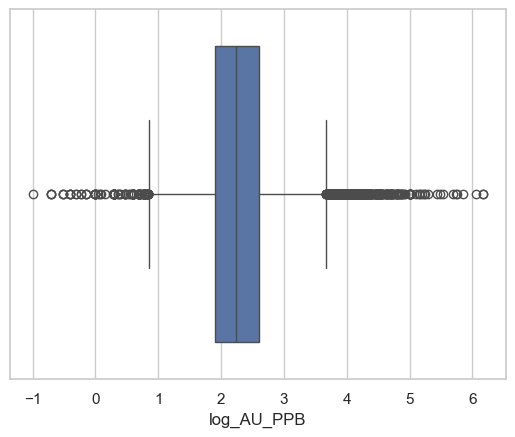

In [1549]:
sns.boxplot(df_usa["log_AU_PPB"], orient="h")

In [1550]:
df_usa["YEAR"] = df_usa["ANALYSIS_DATETIME"].dt.year

Text(0.5, 1.0, 'Distribucion temporal de registros para US')

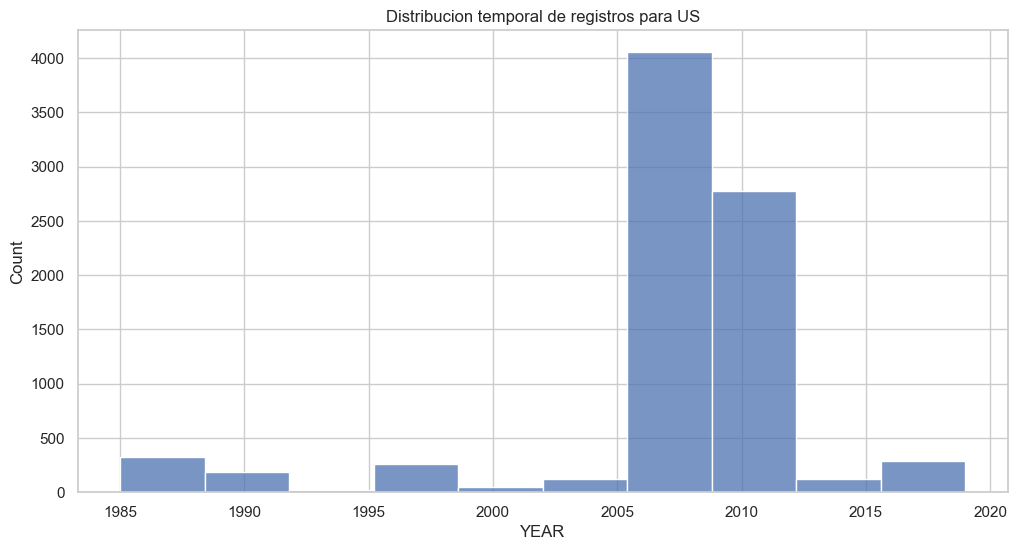

In [1551]:
plt.figure(figsize=(12,6))
sns.histplot(data=df_usa, x="YEAR", bins=10)
plt.title("Distribucion temporal de registros para US")

### 3.1.2 Comentarios variable numerica de mayor interes

- Hay una distancia amplia entre la mediana y el maximo(176ppb vs 1,500,000ppb), tipico en depositos de oro en donde no es extraño encontrar ocasionalmente leyes extraordinariamente altas de este elemento.
- Dado que la mision es encontrar concentraciones anomalamente altas de Au los outliers se consideran como señal y no como error de medicion.

### 3.1.3 Variables categoricas de interes

In [1555]:
df_usa.head()

,DEPOSIT_NAME,DEPOSIT_ENVIRONMENT,DEPOSIT_GROUP,DEPOSIT_TYPE,PRIMARY_COMMODITIES,SECONDARY_COMMODITIES,SAMPLE_UID,FEATURE_TYPE,TOP_DEPTH_M,BASE_DEPTH_M,SAMPLE_DEPOSIT_RELATION,SAMPLE_TYPE,MATERIAL_CLASS,PROVINCE,STRAT_UNIT_NAME,STRAT_UNIT_UID,STRAT_GROUPING,EARTH_MATERIAL_GROUP,EARTH_MATERIAL_QUALIFIER,EARTH_MATERIAL,MODE_OCCURRENCE,ALTERATION,TEXTURE,MINERALS,SAMPLE_DESCRIPTION,SAMPLE_PREPARATION,AG_PPM,AL_PPM,AS_PPM,AU_PPB,B_PPM,BA_PPM,BE_PPM,BI_PPM,BR_PPM,C_WT_PERCENT,CA_PPM,CD_PPM,CE_PPM,CL_PPM,CO_PPM,CR_PPM,CS_PPM,CU_PPM,DY_PPM,ER_PPM,EU_PPM,F_PPM,FE_PPM,GA_PPM,GD_PPM,GE_PPM,HF_PPM,HG_PPB,HO_PPM,IN_PPM,IR_PPM,K_PPM,LA_PPM,LI_PPM,LU_PPM,MG_PPM,MN_PPM,MO_PPM,NA_PPM,NB_PPM,ND_PPM,NI_PPM,OS_PPB,P_PPM,PB_PPM,PD_PPB,PR_PPM,PT_PPB,RB_PPM,RE_PPB,RH_PPB,RU_PPB,S_PPM,SB_PPM,SC_PPM,SE_PPM,SI_PPM,SM_PPM,SN_PPM,SR_PPM,TA_PPM,TB_PPM,TE_PPM,TH_PPM,TI_PPM,TL_PPM,TM_PPM,U_PPM,V_PPM,W_PPM,Y_PPM,YB_PPM,ZN_PPM,ZR_PPM,LREE_PPM,HREE_PPM,REE_PPM,REE_Y_PPM,ANALYSIS_DATETIME,COUNTRY,STATE,log_AU_PPB,YEAR
3641,Ridgeway,Magmatic Hydrothermal,Porphyry,Porphyry Copper ± Gold,"Au, Cu","Ag, Mo, As",AU.7371869,Field Site,NaN,NaN,Unknown,Hand Specimen,Rock,Nan,Nan,Nan,Nan,Metasomatic Rock,Nan,Vein Quartz,Nan,Nan,"Banded, Disseminated, Vein","Chlorite, Pyrite, Quartz, Sericite",OSNACA Low grade or waste sample. Parallel mil...,CS; MTCS,NaN,NaN,NaN,105.00,-20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,-1.00,NaN,NaN,NaN,NaN,"13,600.00",NaN,NaN,NaN,"373,000.00",NaN,25.00,NaN,0.50,NaN,NaN,NaN,"2,700.00",NaN,NaN,NaN,NaN,15.00,NaN,NaN,NaN,120.00,0.00,0.00,0.00,0.00,2016-08-01,Usa,Us-Sc,2.02,"2,016.00"
3706,Ridgeway,Magmatic Hydrothermal,Porphyry,Porphyry Copper ± Gold,"Au, Cu","Ag, Mo, As",AU.7371871,Field Site,NaN,NaN,Unknown,Hand Specimen,Rock,Nan,Nan,Nan,Nan,Rock,Nan,Rock,Nan,Nan,"Banded, Disseminated","Pyrite, Sericite",Shear-banded silica-sericite rock with minor d...,CS; MTCS,NaN,NaN,NaN,288.00,-20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00,NaN,1.00,2.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,-1.00,NaN,NaN,NaN,NaN,"16,800.00",NaN,NaN,NaN,"375,000.00",NaN,5.00,NaN,-0.50,NaN,NaN,NaN,"2,800.00",NaN,NaN,NaN,NaN,10.00,NaN,NaN,NaN,120.00,0.00,0.00,0.00,0.00,2016-08-01,Usa,Us-Sc,2.46,"2,016.00"
3727,Ridgeway,Magmatic Hydrothermal,Porphyry,Porphyry Copper ± Gold,"Au, Cu","Ag, Mo, As",AU.7371870,Field Site,NaN,NaN,Unknown,Hand Specimen,Rock,Nan,Nan,Nan,Nan,Rock,Nan,Rock,Nan,Nan,Vein - Stockwork,Pyrite,Fine-grained grey silica altered rock cut by n...,CS; MTCS,NaN,NaN,NaN,"1,820.00",-20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,8.00,4.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,-1.00,NaN,NaN,NaN,NaN,"101,000.00",52.00,NaN,NaN,"355,000.00",NaN,95.00,NaN,-0.50,NaN,NaN,NaN,"2,200.00",NaN,NaN,NaN,NaN,10.00,NaN,NaN,NaN,270.00,0.00,0.00,0.00,0.00,2016-08-01,Usa,Us-Sc,3.26,"2,016.00"
4606,Climax,Magmatic Hydrothermal,Porphyry,Climax-Type Porphyry Molybdenum,Mo,"W, Re, Sn, Ree",AU.7372022,Field Site,NaN,NaN,Unknown,Hand Specimen,Rock,Nan,Nan,Nan,Nan,Acid Intrusive Rock,Nan,Quartz-Rich Granitoid,Nan,Nan,Nan,Quartz,Quartz-molybdenite vein stockwork with minor p...,CS; MTCS,NaN,NaN,NaN,49.00,40.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.80,NaN,3.00,4.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,-1.00,NaN,NaN,NaN,NaN,"7,000.00",NaN,NaN,NaN,"343,000.00",NaN,30.00,NaN,1.00,NaN,NaN,NaN,"1,100.00",NaN,NaN,NaN,NaN,80.00,NaN,NaN,NaN,210.00,0.00,0.00,0.00,0.00,2016-08-01,Usa,Us-Co,1.69,"2,016.00"
4610,Black Cloud,Magmatic Hydrothermal,Replacement,Replacement Polymetallic,"Pb, Zn, Ag, Au, Cu",Nan,AU.7371899,Field Site,NaN,NaN,Unknown,Hand Specimen,Rock,Nan,Nan,Nan,Nan,Mineralisation,Nan,Massive Sulphide,Nan,N

En la busqueda de areas con potencial es importante conocer la forma de ocurrencia (DEPOSIT_GROUP) del mineral de interes (Au en este caso) y los lugares en donde han sido reportadas dichas ocurrencias (STATE)

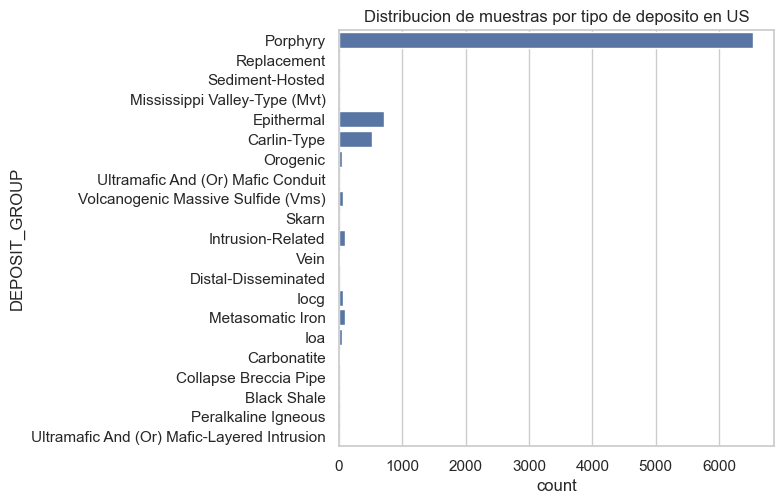

In [1557]:
plt.figure(figsize=(8, 5))
sns.countplot(df_usa, y="DEPOSIT_GROUP")
plt.tight_layout()
plt.title("Distribucion de muestras por tipo de deposito en US")
plt.show()

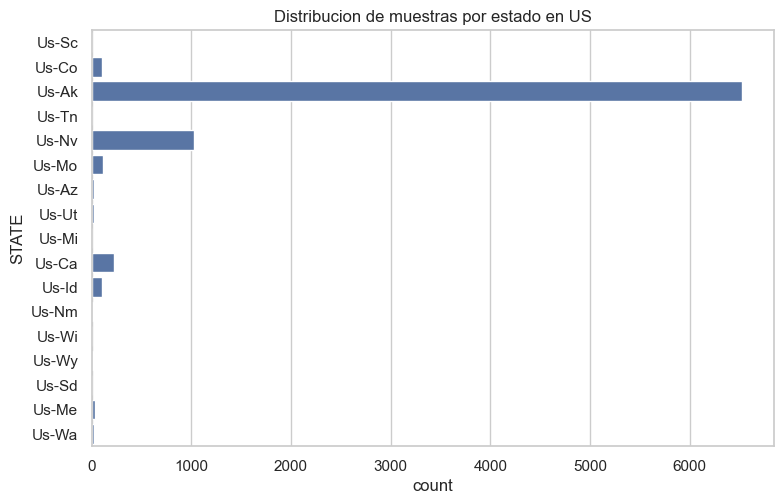

In [1558]:
plt.figure(figsize=(8, 5))
sns.countplot(df_usa, y="STATE")
plt.tight_layout()
plt.title("Distribucion de muestras por estado en US")
plt.show()

### 3.1.4 Comentarios variables categoricas de mayor interes

- Hay una gran disparidad entre la cantidad de muestras por estado, siendo Alaska, Nevada, y California los que concentran la mayoria de los datos, esto no representa necesariamente un sesgo en el muestreo, sino la falta de ocurrencias del mineral en algunos estados.
- Los tipos mas comunes de deposito en el dataset fueron Porphyry, Epithermal y Carling-Type

Lo anterior comienza a proporcionar algunas indicios sobre en que lugares y tipos de deposito es mas comun la presencia de Au.

## 3.2. Analisis bivariado

### 3.2.1 Numerico vs Categorico

Interesa saber principalmente como se distribuyen las concentraciones de Au segun tipo de deposito y luego verificar en que estado se ha reportado el mayor numero de ocurrencias de dicho tipo de deposito

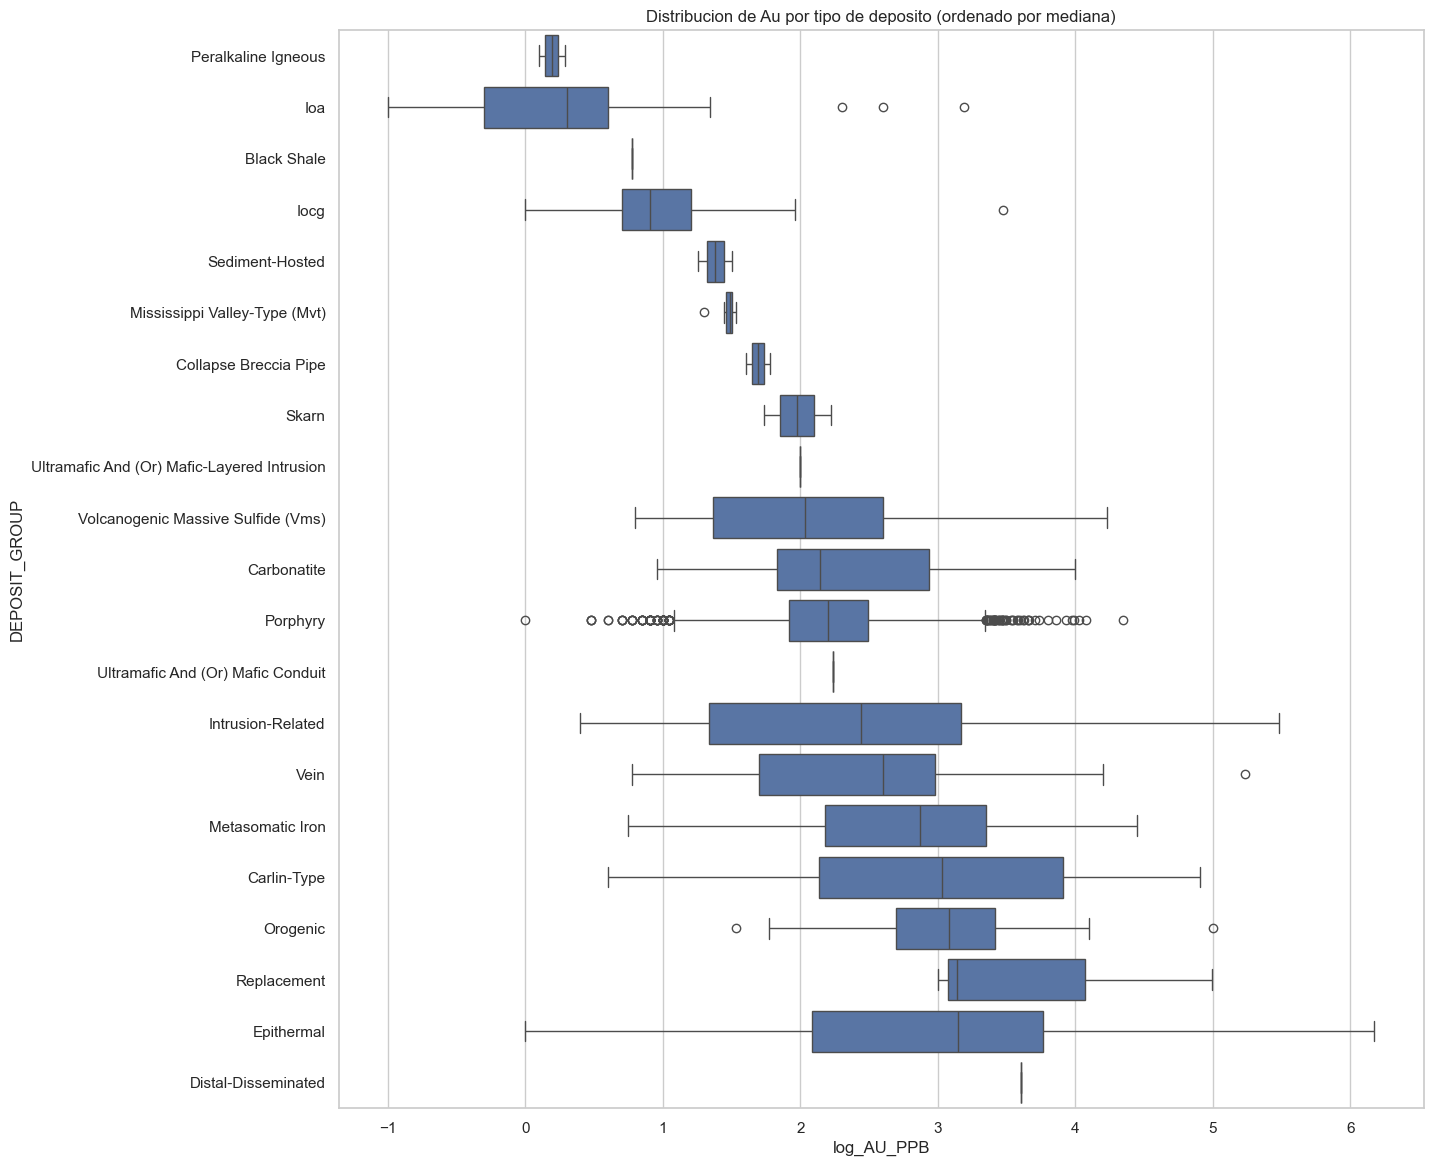

In [1564]:
orden = (df_usa.groupby("DEPOSIT_GROUP")["log_AU_PPB"].median().sort_values().index)

plt.figure(figsize=(14, 14))
sns.boxplot(x="log_AU_PPB", y="DEPOSIT_GROUP", data=df_usa, order=orden)
plt.title("Distribucion de Au por tipo de deposito (ordenado por mediana)")
plt.show()

In [1565]:
df_usa.groupby("DEPOSIT_GROUP")["AU_PPB"].count().sort_values()

DEPOSIT_GROUP
Black Shale                                       1
Ultramafic And (Or) Mafic-Layered Intrusion       1
Ultramafic And (Or) Mafic Conduit                 1
Distal-Disseminated                               1
Collapse Breccia Pipe                             2
Skarn                                             2
Sediment-Hosted                                   2
Peralkaline Igneous                               2
Replacement                                       3
Mississippi Valley-Type (Mvt)                     6
Vein                                             19
Carbonatite                                      19
Ioa                                              48
Orogenic                                         53
Volcanogenic Massive Sulfide (Vms)               64
Iocg                                             65
Intrusion-Related                                92
Metasomatic Iron                                103
Carlin-Type                                     52

In [1566]:
df_epi = df_usa[df_usa["DEPOSIT_GROUP"] == "Epithermal"].copy()

epi_est = (df_epi.groupby("STATE").size().sort_values(ascending=False))
epi_est = epi_est.reset_index(name="Count")
epi_est

,STATE,Count
0,Us-Nv,415
1,Us-Ca,175
2,Us-Co,88
3,Us-Wa,28
4,Us-Sc,3
5,Us-Az,2


### 3.2.2 Comentarios analisis Numerico vs Categorico

- El tipo de deposito que concentra los valores de Au mas altos es del tipo Ephitermal, analizado a la luz de la cantidad de muestras presentes por categoria.
- El estado con la mayor cantidad de ocurrencias del tipo de deposito Ephitermal es el estado de Nevada, seguido por los estados de California y Colorado.
- El hecho de que hayan algunos tipos de deposito con muy pocas muestras no corresponde necesariamente a un sesgo en el muestreo, es mas un indicativo de que muy pocas veces ocurren este tipo de depositos en el pais.

### 3.2.3 Numerico vs Numerico

Conocer con que otros elementos esta correlacionado el oro puede ser una herramienta util en la exploracion de este mineral, asi en los analisis quimicos no aparezcan valores significativamente altos de Au, valores anomalamente altos de elementos que suelen estar relacionados a el pueden sugerir cercania estacial al objetivo.

Para este analisis se utilizara el dataset df_epi, el cual que ya filtraba el tipo de deposito de interes.

In [1571]:
num_cols = df_epi.select_dtypes(include="number").columns
num_cols

Index(['TOP_DEPTH_M', 'BASE_DEPTH_M', 'AG_PPM', 'AL_PPM', 'AS_PPM', 'AU_PPB',
       'B_PPM', 'BA_PPM', 'BE_PPM', 'BI_PPM', 'BR_PPM', 'C_WT_PERCENT',
       'CA_PPM', 'CD_PPM', 'CE_PPM', 'CL_PPM', 'CO_PPM', 'CR_PPM', 'CS_PPM',
       'CU_PPM', 'DY_PPM', 'ER_PPM', 'EU_PPM', 'F_PPM', 'FE_PPM', 'GA_PPM',
       'GD_PPM', 'GE_PPM', 'HF_PPM', 'HG_PPB', 'HO_PPM', 'IN_PPM', 'IR_PPM',
       'K_PPM', 'LA_PPM', 'LI_PPM', 'LU_PPM', 'MG_PPM', 'MN_PPM', 'MO_PPM',
       'NA_PPM', 'NB_PPM', 'ND_PPM', 'NI_PPM', 'OS_PPB', 'P_PPM', 'PB_PPM',
       'PD_PPB', 'PR_PPM', 'PT_PPB', 'RB_PPM', 'RE_PPB', 'RH_PPB', 'RU_PPB',
       'S_PPM', 'SB_PPM', 'SC_PPM', 'SE_PPM', 'SI_PPM', 'SM_PPM', 'SN_PPM',
       'SR_PPM', 'TA_PPM', 'TB_PPM', 'TE_PPM', 'TH_PPM', 'TI_PPM', 'TL_PPM',
       'TM_PPM', 'U_PPM', 'V_PPM', 'W_PPM', 'Y_PPM', 'YB_PPM', 'ZN_PPM',
       'ZR_PPM', 'LREE_PPM', 'HREE_PPM', 'REE_PPM', 'REE_Y_PPM', 'log_AU_PPB',
       'YEAR'],
      dtype='object')

In [1572]:
corr_au = (df_epi[num_cols].corr()["AU_PPB"].drop("log_AU_PPB").sort_values(ascending=False))
corr_au

AU_PPB      1.00
TE_PPM      0.79
F_PPM       0.58
SR_PPM      0.53
B_PPM       0.34
            ... 
RU_PPB       NaN
LREE_PPM     NaN
HREE_PPM     NaN
REE_PPM      NaN
REE_Y_PPM    NaN
Name: AU_PPB, Length: 81, dtype: float64

In [1573]:
df_epi["TE_PPM"].describe()

count     622.00
mean       42.50
std       354.63
min        -0.50
25%         0.30
50%         1.20
75%         4.50
max     7,040.00
Name: TE_PPM, dtype: float64

Ambas variables se trataran en escala logaritmica para poder visualizarlos conjuntamente.

In [1575]:
df_epi_te = df_epi[df_epi["TE_PPM"] > 0].copy()
df_epi_te["log_TE_PPM"] = np.log10(df_epi_te["TE_PPM"])

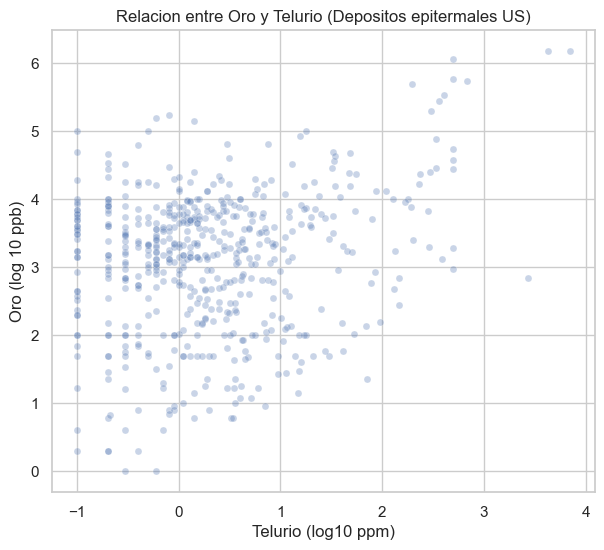

In [1576]:
plt.figure(figsize=(7,6))

sns.scatterplot(x="log_TE_PPM", y="log_AU_PPB", data=df_epi_te, alpha=0.3, s=25)

plt.xlabel("Telurio (log10 ppm)")
plt.ylabel("Oro (log 10 ppb)")
plt.title("Relacion entre Oro y Telurio (Depositos epitermales US)")
plt.show()

# 4. Hallazgos clave

- El tipo de deposito que concentra los valores mas altos de Au es del tipo Epithermal.
- Los estados con mayores ocurrencias reportadas del tipo de deposito Epithermal son los estados de Nevada, California y Colorado.
- El elemento que mayor asociacion presenta al oro dentro del tipo de deposito Epithermal es el telurio, seguido por el fluor y el estroncio.

# 5. Limitaciones

- El tipo de analisis para medir la concentracion de Au y plata (Fire Assay) en una muestra de roca practicamante no ha cambiado a lo largo del tiempo, sin embargo, los analisis para medir el resto de elementos si, de tal manera que un analisis mas profundo de las asociaciones del oro con otro tipo de minerales debe considerar el tipo de analisis de laboratorio aplicado.

# 6. Implicaciones para decision de negocio

- Dado que el foco de la compañia esta puesto en depositos minerales con valores elevados de Au (conocidos como depositos de alta ley), las inversiones debieran priorizar los estados de Nevada, California y Colorado, centrandose en la busqueda de depositos del tipo epithermal.